**PROGETTO**

Questo modello Machine Learning oriented, si pone come obiettivo quello di allenare un classificatore attraverso un processo di train esplicito tramite MLPC, una rete neurale artificiale . Il Dataset da me scelto è "Hello-SimpleAI/HC3", composto da un testo che sarebbero le "questions", ovvero i quesiti e altre labels che invece sono le "anwers", le risposte date da un'intelligenza artificiale, in questo caso Chatgpt e gli esseri umani. Il Task è quello di prevedere se il modello è in grado di capire se a rispodere è l'AI o un essere umano.

In [ ]:
!pip install datasets
!pip install pandas
!pip install scikit-learn
!pip install sentence-transformers
!pip install numpy
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.31.0
    Uninstalling requests-2.31.0:
      Successfully uninstalled requests-2.31.0
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.2
    Uninstalling pyarrow-14.0.2:
      Successfully uninstalled pyarrow-14.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.

In [ ]:
from datasets import load_dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import spacy
import en_core_web_sm
from collections import defaultdict


**DATA PRE-PROCESSING:** Per far si che il lavoro possa iniziare, carico il Dataset cosi da poterlo visualizzare nella sua interezza e i quindi visualizzare il modo in cui è strutturato e suddiviso. Una volta appreso che non è splittato, lo divido in train e data così da potere fare l'addestramento più avanti.
Per non avere problemi durante la separazione dei dati in train e test, trasformo le labels in stringhe e attraverso la libreria Sklearn importo "train_test_split" che applicata ai miei dati li dividerà automaticamente in test e train. Per questioni di comodità applico un sample al mio train data per prendere meno dati mantendoli però presenti a caso così da non alterarlo statisticamente.

In [ ]:
dataset = load_dataset('Hello-SimpleAI/HC3', 'all')
print(dataset)

data = pd.DataFrame(dataset['train'])[['question', 'human_answers', 'chatgpt_answers']]
data['human_answers'] = data['human_answers'].astype(str)
data['chatgpt_answers'] = data['chatgpt_answers'].astype(str)

train_data, test_data = train_test_split(data, test_size=0.33, random_state=42)

train = train_data.sample(16000)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/24322 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'human_answers', 'chatgpt_answers', 'source'],
        num_rows: 24322
    })
})


**POS TAGGING** A questo punto, avendo a mia disposizione le labels inerenti a Human answers e Chatgpt answers, attraverso la libreria Spacy, mi calcolo per ciascuna label il totale di ogni POS tag, così da poter paragonare quali linguistic features sono più usate e soprattuto vedere da chi.
Carico il modello di spacy "en_core_web_sm" che ho scelto perchè il mio dataset è in lingua inglese. Conseguentemente ho creato per ciascuna delle mie labels un defaultdict che quando accede a un valore non noto lo inserisce automaticamente nel mio dizionario. I values saranno invece un calcolatore per ogni POS tag che verrà incrementato ogni volta che quella classe di linguistic feature viene trovata nel text ('questions').

In [ ]:

nlp = spacy.load('en_core_web_sm')

count_POS_humans = defaultdict(int)
count_POS_chatgpt = defaultdict(int)

for text in data['human_answers']:
    doc = nlp(text)
    for word in doc:
        count_POS_humans[word.pos_] += 1

print("POS HUMANS: ", count_POS_humans)

for text in data['chatgpt_answers']:
    doc = nlp(text)
    for word in doc:
        count_POS_chatgpt[word.pos_] += 1

print("POS CHATGPT: ", count_POS_chatgpt)

POS HUMANS:  defaultdict(<class 'int'>, {'X': 43249, 'PUNCT': 1164718, 'ADV': 431162, 'PRON': 680383, 'VERB': 911826, 'ADJ': 549606, 'NOUN': 1478403, 'ADP': 725224, 'PROPN': 259368, 'CCONJ': 246408, 'DET': 674482, 'AUX': 483462, 'PART': 228207, 'SCONJ': 203316, 'NUM': 105604, 'SYM': 23502, 'INTJ': 12829, 'SPACE': 13147})
POS CHATGPT:  defaultdict(<class 'int'>, {'X': 27527, 'PUNCT': 572012, 'PRON': 369417, 'VERB': 607724, 'ADJ': 413497, 'NOUN': 1110879, 'AUX': 358107, 'ADP': 495121, 'CCONJ': 217799, 'DET': 481047, 'PROPN': 138745, 'ADV': 165623, 'NUM': 38440, 'PART': 181952, 'SCONJ': 128541, 'SYM': 3729, 'INTJ': 2631, 'SPACE': 63})


**POS Frequency Comparison**-->**ISTOGRAMMA** Per visualizzare i grafici genero un istogramma. Riporto i DefaultDict a dizionari normali per essere compatibili con il plotting della libreria "matplotlib.pyplot"

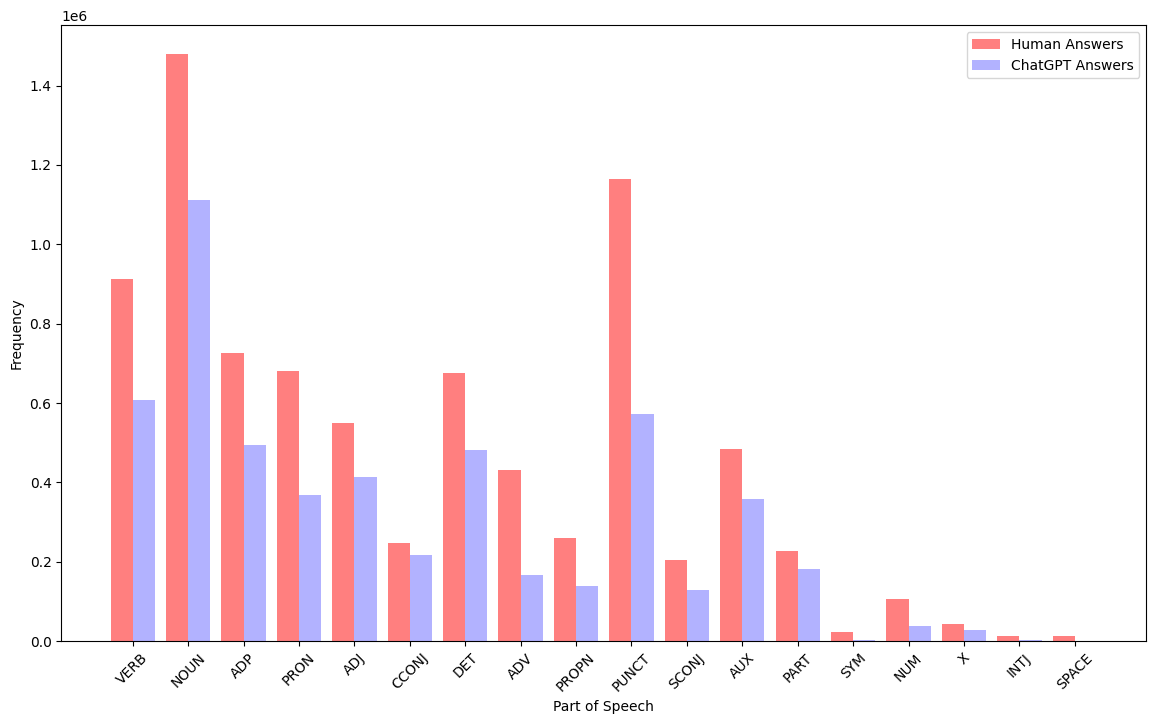

In [ ]:


count_POS_humans = dict(count_POS_humans)
count_POS_chatgpt = dict(count_POS_chatgpt)

all_keys = set(count_POS_humans.keys()).union(set(count_POS_chatgpt.keys()))
human_POS = {key: count_POS_humans.get(key, 0) for key in all_keys}
chatgpt_POS = {key: count_POS_chatgpt.get(key, 0) for key in all_keys}

width = 0.4
x = range(len(all_keys))


fig, ax = plt.subplots(figsize=(14, 8))


ax.bar([pos - width/2 for pos in x], human_POS.values(), width=width, alpha=0.5, color='red', label='Human Answers')
ax.bar([pos + width/2 for pos in x], chatgpt_POS.values(), width=width, alpha=0.3, color='blue', label='ChatGPT Answers')

ax.set_xticks(x)
ax.set_xticklabels(all_keys, rotation=45)


ax.set_xlabel('Part of Speech')
ax.set_ylabel('Frequency')
ax.legend()


plt.show()

**EMBEDDING GENERATION** Dopo aver calcolato le part of speech, procedo con la craezione di una nuova label che unisca 'human_answers' e 'chat_answers' in 'answers', dove 1 corrisponde a human e 0 a chat. Utilizzo la funzione rename per cambiare nome alla label e poi concat per unirle in un'unica colonna.
Creato un nuovo Dataframe lo splitto un'altra volta in train e test calcolando con "SentenceTransformer" gli embeddings di train e test per poter procedere con l'addestramento del modello.

In [ ]:

data_human = data[['question', 'human_answers']].copy()
data_human['label'] = 1
data_human.rename(columns={'human_answers': 'answer'}, inplace=True)


data_chatgpt = data[['question', 'chatgpt_answers']].copy()
data_chatgpt['label'] = 0
data_chatgpt.rename(columns={'chatgpt_answers': 'answer'}, inplace=True)


labels = pd.concat([data_human, data_chatgpt], ignore_index=True)
data_new= labels.sample(16000)
print("data_new: ",data_new)


data2 = data_new
train_data2, test_data2 = train_test_split(data2, test_size=0.33, random_state=42)
print("splittato: ",data2)
#print("Train Data:\n", train_data)
#print("Test Data:\n", test_data2)

model = SentenceTransformer("distiluse-base-multilingual-cased-v1")
train_embeddings = model.encode(train_data2['answer'].tolist())
test_embeddings = model.encode(test_data2['answer'].tolist())

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


data_new:                                                  question  \
14714  Dumbass question about water ... Soooo , if th...   
17114                                   what are add ons   
27261  Why do we scratch an itch ? What makes it so p...   
17588                        what is the origin of fiona   
20733  What is the formula for determining estimated ...   
...                                                  ...   
15841  Why all the hubbub about Hurricane Sandy when ...   
33545  How do planets stay in orbit ? If they are att...   
28134  Why do we have swear words ? Who decided they ...   
28193  How can a public University ban smoking everyw...   
24568  Why do Mobile Video Games have so many commerc...   

                                                  answer  label  
14714  ["You can . Combusting hydrogen yields water ....      1  
17114  ['Plug-in (computing) , a piece of software wh...      1  
27261  ['Scratching an itch feels good because it sen...      0  
1758

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


**TRAINING OF THE MODEL** Calcolati gli embedding con SentenceBert posso iniziare a fare il vero e prorpio train del modello con tutti i miei dati di train.

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(24000,), random_state=42)
mlp.fit(train_embeddings, train_data2['label'])

MLPClassifier(hidden_layer_sizes=(24000,), random_state=42)

**Validation** Adesso per validare uso mlp.predict(test_embeddings) che applica il modello addestrato ai dati di test e restituisce le predizioni.

In [ ]:
predictions = mlp.predict(test_embeddings)
print(predictions)

[0 0 0 ... 0 0 0]


**Statistics** Rapporto di classificazione

              precision    recall  f1-score   support

     chatgpt       0.93      0.94      0.93      2592
       human       0.94      0.93      0.93      2688

    accuracy                           0.93      5280
   macro avg       0.93      0.93      0.93      5280
weighted avg       0.93      0.93      0.93      5280

report:  {'0': {'precision': 0.9253505115574081, 'recall': 0.9421296296296297, 'f1-score': 0.9336646912636208, 'support': 2592}, '1': {'precision': 0.9432033320711851, 'recall': 0.9267113095238095, 'f1-score': 0.9348845937324076, 'support': 2688}, 'accuracy': 0.9342803030303031, 'macro avg': {'precision': 0.9342769218142966, 'recall': 0.9344204695767195, 'f1-score': 0.9342746424980142, 'support': 5280}, 'weighted avg': {'precision': 0.9344392201826036, 'recall': 0.9342803030303031, 'f1-score': 0.9342857325204577, 'support': 5280}}


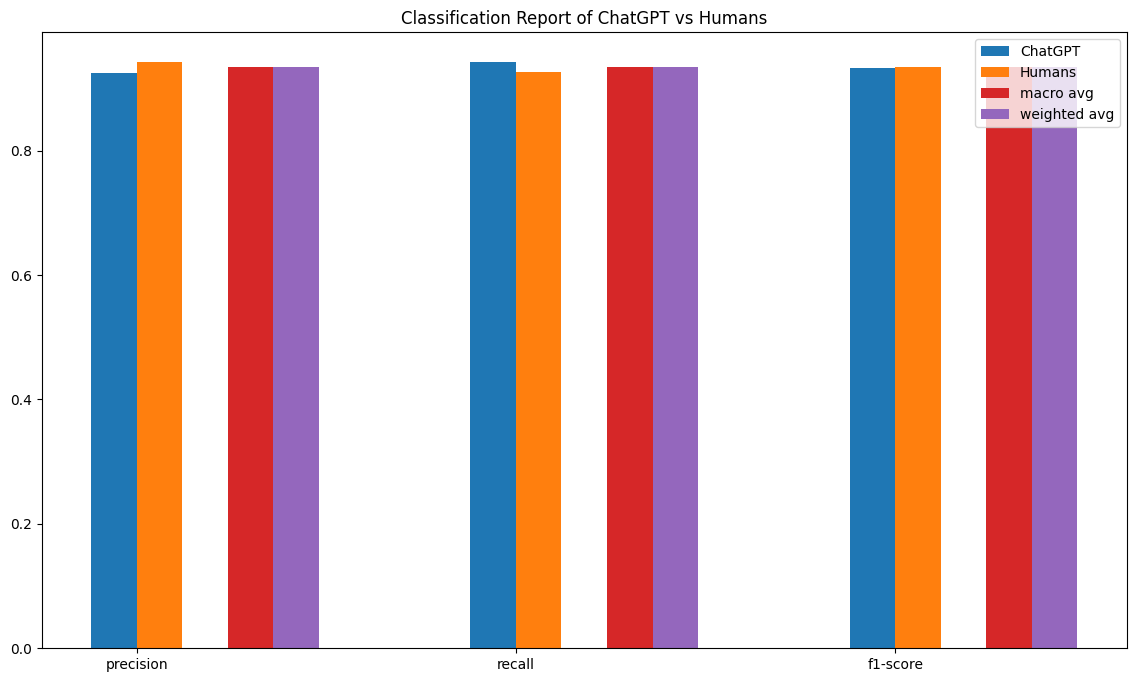

In [ ]:

mapping = {0:'chatgpt', 1:'human'}
print(classification_report(test_data2['label'], predictions,target_names = mapping.values()))
report = classification_report(test_data2['label'], predictions, output_dict=True)
print("report: ",report)

rep = ('precision', 'recall', 'f1-score')
class_rep_dict = {
    'ChatGPT': np.array([report['0'][metric] for metric in rep]),
    'Humans': np.array([report['1'][metric] for metric in rep]),
    'accuracy': np.array([report['accuracy']]),
    'macro avg': np.array([report['macro avg'][metric] for metric in rep]),
    'weighted avg': np.array([report['weighted avg'][metric] for metric in rep])
}

width = 0.6

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

x = np.arange(len(rep))
for i, (c, values) in enumerate(class_rep_dict.items()):
    if len(values) == len(rep):
        ax.bar(x + i * width/len(class_rep_dict), values, width/len(class_rep_dict), label=c, color=colors[i % len(colors)])

ax.set_xticks(x + width / (2 * len(class_rep_dict)))
ax.set_xticklabels(rep)
ax.set_title('Classification Report of ChatGPT vs Humans')
ax.legend()

plt.show()

**CONSIDERAZIONI** Il modello mostra un'elevata accuratezza generale (93%) nella classificazione tra "chatgpt" e "human".
Le metriche di precisione sono entrambe elevate per entrambe le classi (chatgpt 0.94 e human 0.93), questo mette in luce che il modello è bilanciato e performa bene sia nel riconoscere correttamente le istanze di "chatgpt" che quelle di "human". Il modello avrebbe potuto avere anche un accuratezza maggiore se si fosse utilizzato tutto il dataset perchè ovviamente più dati vengono sottoposti al modello più la sua accuracy sarà alta.